### **Full name**: Nurana Aliyarli, **rank**:3

# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
from scipy.stats import pearsonr, spearmanr

pairs=[('mpg','weight'),('displacement','horsepower'),('horsepower','acceleration')]

for x, y in pairs:
    pearson_corr = mpg[x].corr(mpg[y], method='pearson')
    spearman_corr = mpg[x].corr(mpg[y], method='spearman')

    pearson_p = pearsonr(mpg[x], mpg[y])[1]
    spearman_p = spearmanr(mpg[x], mpg[y])[1]

    print(f"{x} vs {y}")
    print(f" Pearson : {pearson_corr:.3f} | p-value: {pearson_p:.5f}")
    print(f" Spearman: {spearman_corr:.3f} | p-value: {spearman_p:.5f}")
    print("-" * 40)            

mpg vs weight
 Pearson : -0.832 | p-value: 0.00000
 Spearman: -0.876 | p-value: 0.00000
----------------------------------------
displacement vs horsepower
 Pearson : 0.897 | p-value: 0.00000
 Spearman: 0.876 | p-value: 0.00000
----------------------------------------
horsepower vs acceleration
 Pearson : -0.689 | p-value: 0.00000
 Spearman: -0.658 | p-value: 0.00000
----------------------------------------


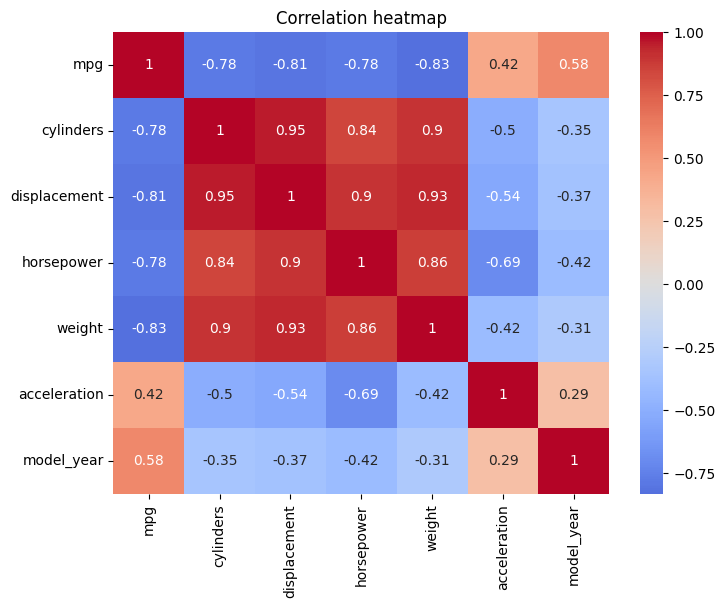

In [4]:
# Correlation heatmap
corr=mpg.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',center=0)
plt.title('Correlation heatmap')
plt.show()


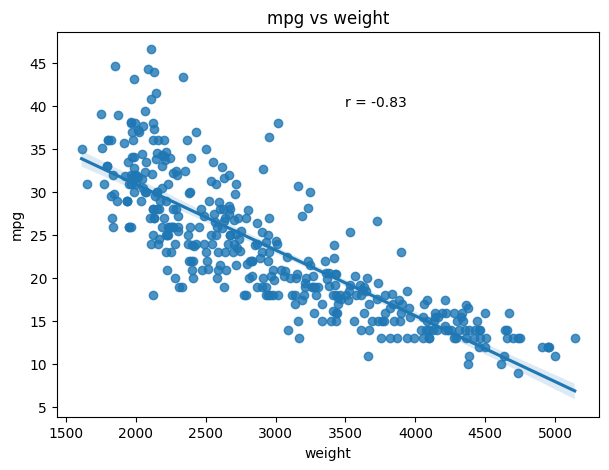

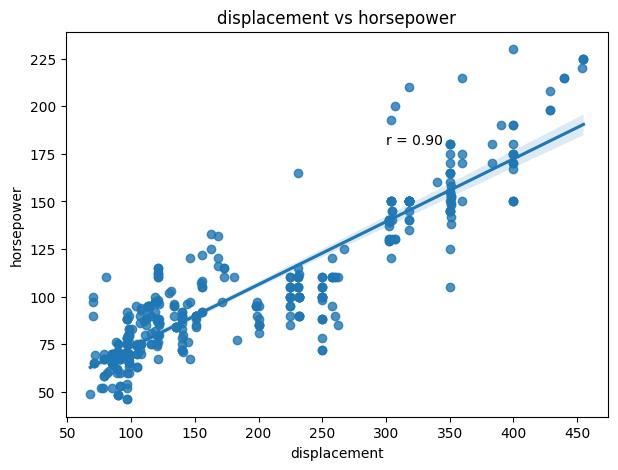

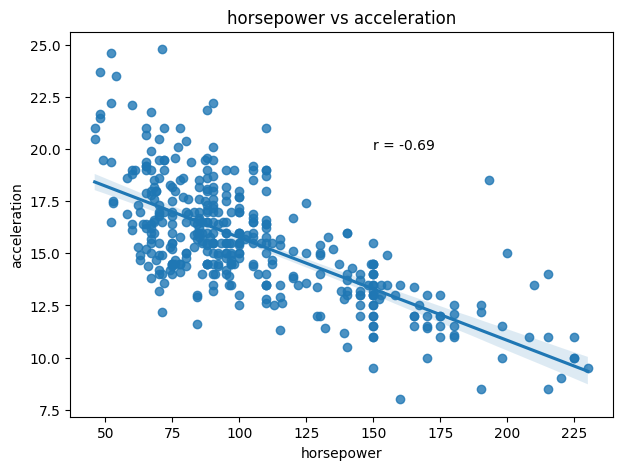

In [5]:
# Scatter plots with regression lines
#scatter plot 1 
plt.figure(figsize=(7,5))
sns.regplot(data=mpg,x='weight',y='mpg')

corr1=mpg['mpg'].corr(mpg['weight'])
plt.text(3500, 40, f'r = {corr1:.2f}')
plt.title('mpg vs weight')
plt.show()

#scatter plot 2
plt.figure(figsize=(7,5))
sns.regplot(data=mpg, x='displacement', y='horsepower')

corr2 = mpg['displacement'].corr(mpg['horsepower'])
plt.text(300, 180, f'r = {corr2:.2f}')
plt.title('displacement vs horsepower')
plt.show()

#scatter plot 3
plt.figure(figsize=(7,5))
sns.regplot(data=mpg, x='horsepower', y='acceleration')

corr3 = mpg['horsepower'].corr(mpg['acceleration'])
plt.text(150, 20, f'r = {corr3:.2f}')
plt.title('horsepower vs acceleration')
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Your answer here…

## 4. Pearson vs. Spearman Correlation

Pearson correlation measures the strength of a **linear** relationship between two continuous variables. It works best when the data is normally distributed, the relationship follows a straight line, and there are no strong outliers. Spearman correlation is a rank-based measure that captures **monotonic** relationships — meaning it still works when the trend is consistent but not perfectly linear, and it is more robust to outliers.

All six correlations computed below were statistically significant with p-values well below 0.001, so none of the results are due to chance.

**displacement vs. horsepower** is the clearest case for Pearson. The Pearson r = 0.897 and Spearman ρ = 0.876 are very close, which tells us the relationship is both strongly linear and monotonic with no major distortion from outliers. When these two values are this close, it confirms that the linear assumption holds and Pearson is appropriate.

**mpg vs. weight** shows a more interesting pattern. Pearson r = −0.832 but Spearman ρ = −0.876 — Spearman is noticeably stronger. This gap suggests the relationship is slightly non-linear, which also matches the scatter plot where the point spread widens at lower weights (heteroscedasticity). Here Spearman gives a more accurate picture of the true strength of the relationship.

**horsepower vs. acceleration** is the weakest pair overall. Pearson r = −0.689 and Spearman ρ = −0.658, meaning Pearson is actually slightly stronger here. This tells us the relationship is reasonably linear and that outliers are not pulling the result in a misleading direction. In this case Pearson is the more appropriate choice since the linear assumption is not being violated.

In general, when Pearson and Spearman values are close, the linear assumption holds and either method works. When Spearman is noticeably higher, it signals non-linearity or outliers, and Spearman should be preferred.


---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

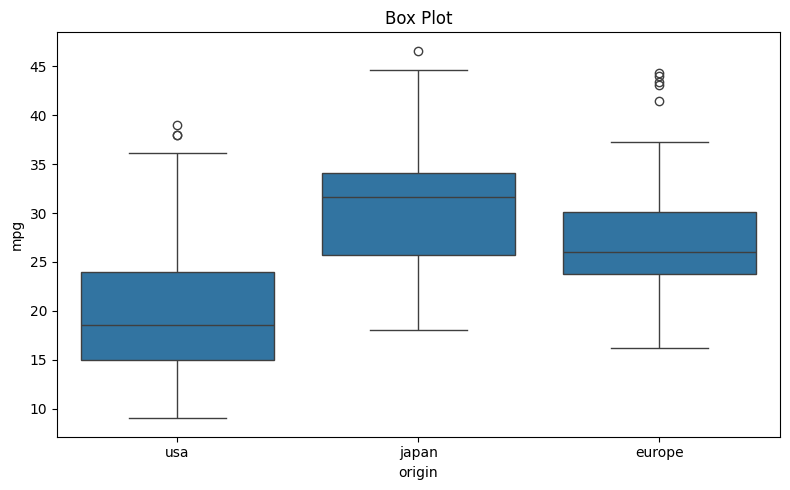

In [6]:
# Distribution visualization by origin
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=mpg, x='origin', y='mpg', ax=ax)
ax.set_title('Box Plot')
plt.tight_layout()
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test
usa = mpg[mpg['origin']=='usa']['mpg']
europe = mpg[mpg['origin']=='europe']['mpg']
japan = mpg[mpg['origin']=='japan']['mpg']

for name, data in [('usa', usa), ('europe', europe), ('japan', japan)]:
    stat, p = stats.shapiro(data)
    print(name, p)

levene_stat, levene_p = stats.levene(usa, europe, japan)
print("Levene p-value:", levene_p)

usa 4.756933592330299e-09
europe 0.005421695996788568
japan 0.24196747173744043
Levene p-value: 0.9175294106303586


Shapiro-Wilk results show that the USA and Europe groups are not normally distributed because their p-values are below 0.05, while the Japan group is approximately normally distributed since its p-value is above 0.05. On the other hand, the Levene test result is 0.91, which is well above 0.05, indicating that the group variances are homogeneous.

Although two of the three groups fail the normality assumption, one-way ANOVA is generally considered robust to normality violations when group sizes are reasonably large, as is the case here (USA n≈245, Europe n≈68, Japan n≈79). The homogeneity of variance assumption is met (Levene p = 0.91), which is the more critical condition for ANOVA. As an additional check, a Kruskal-Wallis test could be used as a non-parametric alternative to confirm the result.

In [8]:
# One-way ANOVA
f_stat, p_value = stats.f_oneway(usa, europe, japan)

overall_mean = mpg['mpg'].mean()
group_means = mpg.groupby('origin')['mpg'].mean()

ss_between = sum(len(mpg[mpg['origin']==g]) * (group_means[g] - overall_mean)**2
                 for g in mpg['origin'].unique())

ss_total = ((mpg['mpg'] - overall_mean)**2).sum()
eta_squared = ss_between / ss_total

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.5f}")
print(f"Eta-squared: {eta_squared:.4f}")

F-statistic: 96.6015
p-value: 0.00000
Eta-squared: 0.3318


The one-way ANOVA results show that there is a statistically significant difference in mean mpg across the three origin groups: usa, europe, and japan. The F-statistic is 96.6015, which means that the variation between the group means is much larger than the variation within the groups. In other words, the differences among the origin groups are too large to be explained by random variation alone.

The p-value is 0.00000, which is far below the common significance threshold of 0.05. This means that we reject the null hypothesis that all three group means are equal. Therefore, we conclude that at least one origin group has a mean mpg that is significantly different from the others.

The eta-squared effect size is 0.3318. This means that origin explains about 33.18% of the total variance in mpg. This is considered a large effect size, so the difference is not only statistically significant but also practically meaningful. In other words, the origin of the cars has a strong relationship with fuel efficiency in this dataset.

In [9]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(mpg['mpg'], mpg['origin'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

Your answer here…

The Tukey HSD results show that all three origin groups are significantly different from each other, so the mean mpg values are not the same across usa, europe, and japan. Europe and Japan differ because their adjusted p-value is 0.0203, which is below 0.05, Europe and USA also differ because the adjusted p-value is 0.0000, and Japan and USA differ as well because their adjusted p-value is also 0.0000. Among these comparisons, Japan and USA show the largest mean difference. This means that each origin group has its own mpg pattern in the dataset. The eta-squared value is 0.3318, which indicates a large effect size, meaning that origin explains about 33% of the total variation in mpg. In this dataset, It is a large effect because the eta-squared value is much higher than the large-effect threshold of 0.14.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].to_numpy()
y = mpg["origin"].astype(str).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(pd.Series(y_test).value_counts().to_dict())

Train: 294, Test: 98
{'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=SEED, max_iter=1000))
])

dt_clf = DecisionTreeClassifier(random_state=SEED)

lr_pipe.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)

y_pred_lr = lr_pipe.predict(X_test)
y_pred_dt = dt_clf.predict(X_test)

In [12]:
# Classification reports
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

Logistic Regression
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

Decision Tree
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [13]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_scores = []
    skipped = 0

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for _ in range(n_boot):
        indices = rng.randint(0, n, size=n)
        yt, yp = y_true[indices], y_pred[indices]

        try:
            score = metric_fn(yt, yp)
            if np.isfinite(score):
                boot_scores.append(score)
        except Exception:
            skipped += 1
            continue

    boot_scores = np.array(boot_scores)

    point_estimate = metric_fn(y_true, y_pred)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)

    return point_estimate, ci_lower, ci_upper, boot_scores


In [ ]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
from sklearn.metrics import f1_score, precision_score, recall_score

labels = np.unique(y_test)

# Logistic Regression
f1_lr, f1_lr_lo, f1_lr_hi, _ = bootstrap_metric(
    y_test, y_pred_lr,
    lambda yt, yp: f1_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

prec_lr, prec_lr_lo, prec_lr_hi, _ = bootstrap_metric(
    y_test, y_pred_lr,
    lambda yt, yp: precision_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

rec_lr, rec_lr_lo, rec_lr_hi, _ = bootstrap_metric(
    y_test, y_pred_lr,
    lambda yt, yp: recall_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

# Decision Tree
f1_dt, f1_dt_lo, f1_dt_hi, _ = bootstrap_metric(
    y_test, y_pred_dt,
    lambda yt, yp: f1_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

prec_dt, prec_dt_lo, prec_dt_hi, _ = bootstrap_metric(
    y_test, y_pred_dt,
    lambda yt, yp: precision_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

rec_dt, rec_dt_lo, rec_dt_hi, _ = bootstrap_metric(
    y_test, y_pred_dt,
    lambda yt, yp: recall_score(yt, yp, labels=labels, average='macro', zero_division=0)
)

print("Logistic Regression")
print(f"F1: {f1_lr:.4f} 95% CI [{f1_lr_lo:.4f}, {f1_lr_hi:.4f}]")
print(f"Precision: {prec_lr:.4f} 95% CI [{prec_lr_lo:.4f}, {prec_lr_hi:.4f}]")
print(f"Recall: {rec_lr:.4f} 95% CI [{rec_lr_lo:.4f}, {rec_lr_hi:.4f}]")

print("\nDecision Tree")
print(f"F1: {f1_dt:.4f} 95% CI [{f1_dt_lo:.4f}, {f1_dt_hi:.4f}]")
print(f"Precision: {prec_dt:.4f} 95% CI [{prec_dt_lo:.4f}, {prec_dt_hi:.4f}]")
print(f"Recall: {rec_dt:.4f} 95% CI [{rec_dt_lo:.4f}, {rec_dt_hi:.4f}]")


In [ ]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
metrics = ['F1', 'Precision', 'Recall']

lr_scores = [f1_lr, prec_lr, rec_lr]
lr_low = [f1_lr - f1_lr_lo, prec_lr - prec_lr_lo, rec_lr - rec_lr_lo]
lr_high = [f1_lr_hi - f1_lr, prec_lr_hi - prec_lr, rec_lr_hi - rec_lr]

dt_scores = [f1_dt, prec_dt, rec_dt]
dt_low = [f1_dt - f1_dt_lo, prec_dt - prec_dt_lo, rec_dt - rec_dt_lo]
dt_high = [f1_dt_hi - f1_dt, prec_dt_hi - prec_dt, rec_dt_hi - rec_dt]

x = np.arange(len(metrics))

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(x - 0.1, lr_scores,
            yerr=[lr_low, lr_high],
            fmt='o', capsize=5, label='Logistic Regression')

ax.errorbar(x + 0.1, dt_scores,
            yerr=[dt_low, dt_high],
            fmt='o', capsize=5, label='Decision Tree')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Bootstrap 95% Confidence Intervals')
ax.legend()

plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

Your answer here…

I would recommend Decision Tree because when I compared both models, it performed better in all main metrics. In the classification report, its macro F1 score was **0.83**, while Logistic Regression gave **0.72**, which showed me that Decision Tree handled the three origin classes more successfully overall instead of performing well only on one class. I also saw that precision and recall were higher, so the model made fewer classification mistakes across the dataset, especially for japan and usa.

For the bootstrap confidence intervals, the F1 interval for Decision Tree was **[0.7299, 0.9210]**, while Logistic Regression had **[0.5977, 0.8223]**. This already showed me that Decision Tree keeps stronger performance even when I repeatedly resample the test set. The same pattern appeared for precision and recall, where the Decision Tree intervals stayed consistently higher. The intervals are not extremely narrow, so I would not say the uncertainty is small, but they are still informative enough to show a stable advantage for Decision Tree. I also paid attention to the lower bounds, because they tell me how the model behaves in less favorable resamples, and here Decision Tree still stays stronger than Logistic Regression.

Because of that, I am reasonably confident in recommending Decision Tree for this dataset. The confidence intervals still overlap a little, so I cannot say the difference is absolute in every possible sample, but the overall pattern stays consistent enough to support this choice.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

*Write your 150–250 word summary here…*

When I summarized the correlation results, I focused on mpg because it directly represents fuel efficiency in this dataset. The strongest relationship was between mpg and weight (-0.832), meaning heavier cars tend to have lower fuel efficiency. I also found strong negative correlations with displacement (-0.805), horsepower (-0.778), and cylinders (-0.778), so larger and more powerful engines generally consume more fuel. The strongest positive correlation was model_year (0.581), suggesting newer cars tend to be more fuel efficient.

To compare origins, I ran ANOVA on mpg and got a significant result (F = 96.60, p < 0.001). Since ANOVA only shows that a difference exists somewhere, I followed it with Tukey's HSD. All three origin pairs were significant: europe-japan, europe-usa, and japan-usa, with japan and usa showing the largest mean difference (-10.42). The effect size was eta-squared = 0.3318, meaning origin explains about 33% of the total variation in mpg, which is a strong group effect.

For classification, I recommend Decision Tree because it outperformed Logistic Regression in macro F1 (0.83 vs 0.72), precision, and recall. Its bootstrap CIs were consistently higher, with an F1 CI of [0.73, 0.92] versus [0.60, 0.82], and the lower bounds confirm Decision Tree stays stronger even in less favorable resamples. One caveat is that the default max_depth=None setting can cause overfitting, so comparing training versus test accuracy or applying pruning would be a worthwhile next step.